# 01 · Data Understanding

**Project:** Instacart Customer & Market Basket Analysis
**Phase 1 of the brief.** Nothing is cleaned or changed here. The only job of this
notebook is to find out what we actually have, and to write down what is wrong with it
*before* anyone forms an opinion from it.

Deliverables produced here:

1. **Data Dictionary** — every column, type, meaning, key role
2. **Data Relationship / Data Model** — how the six tables connect
3. **Initial Data Quality Report** — missing values, duplicates, invalid values, distributions

The six source files are the public Instacart *"The Instacart Online Grocery Shopping
Dataset 2017"* release: `orders`, `products`, `aisles`, `departments`,
`order_products__prior`, `order_products__train`.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import instacart as ic
plt = ic.set_style()
pd.set_option("display.width", 170, "display.max_columns", 40)
print("pandas", pd.__version__)

pandas 3.0.6


## 1.1 Load the raw files

Explicit dtypes on load, for two reasons: `order_products__prior` has 32.4M rows and
pandas' default int64 would cost ~4x the memory it needs, and fixing the type at the
door means a silently-coerced column can't quietly become a float later.

In [2]:
raw = {}
for name in ["aisles", "departments", "products", "orders",
             "order_products__prior", "order_products__train"]:
    raw[name] = ic.load_raw(name)
    print(f"{name:>24}: {len(raw[name]):>12,} rows x {raw[name].shape[1]} cols")

aisles, depts, prods = raw["aisles"], raw["departments"], raw["products"]
orders, prior, train = raw["orders"], raw["order_products__prior"], raw["order_products__train"]

                  aisles:          134 rows x 2 cols
             departments:           21 rows x 2 cols
                products:       49,688 rows x 4 cols


                  orders:    3,421,083 rows x 7 cols


   order_products__prior:   32,434,489 rows x 4 cols
   order_products__train:    1,384,617 rows x 4 cols


In [3]:
for name, df in raw.items():
    print(f"\n=== {name} " + "="*(60-len(name)))
    print(df.head(3).to_string(index=False))


=== aisles ======================================================
 aisle_id                 aisle
        1 prepared soups salads
        2     specialty cheeses
        3   energy granola bars

=== departments =================================================
 department_id department
             1     frozen
             2      other
             3     bakery

=== products ====================================================
 product_id                         product_name  aisle_id  department_id
          1           Chocolate Sandwich Cookies        61             19
          2                     All-Seasons Salt       104             13
          3 Robust Golden Unsweetened Oolong Tea        94              7

=== orders ======================================================
 order_id  user_id eval_set  order_number  order_dow  order_hour_of_day  days_since_prior_order
  2539329        1    prior             1          2                  8                     NaN
  2398795   

## 1.2 Shape, types and memory

In [4]:
shape_tbl = pd.DataFrame([{
    "table": n, "rows": len(d), "columns": d.shape[1],
    "memory_MB": round(d.memory_usage(deep=True).sum()/1e6, 1),
    "column_list": ", ".join(d.columns)} for n, d in raw.items()])
display(shape_tbl)

,table,rows,columns,memory_MB,column_list
0,aisles,134,2,0.0,"aisle_id, aisle"
1,departments,21,2,0.0,"department_id, department"
2,products,49688,4,3.1,"product_id, product_name, aisle_id, department_id"
3,orders,3421083,7,58.2,"order_id, user_id, eval_set, order_number, ord..."
4,order_products__prior,32434489,4,356.8,"order_id, product_id, add_to_cart_order, reord..."
5,order_products__train,1384617,4,15.2,"order_id, product_id, add_to_cart_order, reord..."


In [5]:
for name, df in raw.items():
    print(f"\n{name}:"); print(df.dtypes.to_string())


aisles:
aisle_id    int64
aisle         str

departments:
department_id    int64
department         str

products:
product_id       int64
product_name       str
aisle_id         int64
department_id    int64

orders:
order_id                     int32
user_id                      int32
eval_set                  category
order_number                 int16
order_dow                     int8
order_hour_of_day             int8
days_since_prior_order     float32

order_products__prior:
order_id             int32
product_id           int32
add_to_cart_order    int16
reordered             int8

order_products__train:
order_id             int32
product_id           int32
add_to_cart_order    int16
reordered             int8


### Reading of the shape

The six tables are a textbook star-ish schema: four small dimension/bridge tables
(`departments` 21 rows, `aisles` 134, `products` 49,688, `orders` 3.42M) and one very
large fact table split across two files (`order_products__prior` 32.4M +
`order_products__train` 1.38M = **33.8M basket lines**).

`orders` is interesting: it is at *order* grain, not customer grain — there is no
customer table at all in this release. Everything we will ever know about a customer has
to be *derived* from their orders. That shapes the whole project: the customer table in
notebook 02 is something we build, not something we are given.

## 1.3 Data Dictionary

Every column, its type, what it means, and its key role. The "meaning" column is the part
that matters — several of these fields are easy to misread.

In [6]:
DICT = [
 # table, column, dtype, key, description
 ("aisles","aisle_id","int64","PK","Surrogate id for a shelf/aisle (1–134)."),
 ("aisles","aisle","object","","Aisle name, e.g. 'fresh fruits'. Includes the placeholder values 'missing' and 'other'."),
 ("departments","department_id","int64","PK","Surrogate id for a department (1–21)."),
 ("departments","department","object","","Department name, e.g. 'produce'. Includes the placeholder value 'missing'."),
 ("products","product_id","int64","PK","Surrogate id for a product/SKU (1–49,688)."),
 ("products","product_name","object","","Free-text product name. Not unique: 99 names are shared by more than one product_id."),
 ("products","aisle_id","int64","FK → aisles","The one aisle this product sits in."),
 ("products","department_id","int64","FK → departments","The one department this product sits in. Note products carries BOTH FKs, so aisle→department is denormalised."),
 ("orders","order_id","int64","PK","Surrogate id for one order/basket."),
 ("orders","user_id","int64","FK (implicit)","The customer. There is no users table; this is the only customer identifier in the dataset."),
 ("orders","eval_set","object","","Which file holds this order's contents: 'prior' (history), 'train' (the customer's most recent order, contents known), 'test' (most recent order, contents NOT released)."),
 ("orders","order_number","int64","","Sequence position of this order for this customer, 1 = their first ever. Caps at 100."),
 ("orders","order_dow","int64","","Day of week, 0–6. The release does NOT document which day is 0."),
 ("orders","order_hour_of_day","int64","","Hour the order was placed, 0–23. Local time, no date is given."),
 ("orders","days_since_prior_order","float64","","Days since this customer's previous order. NULL on a first order (no previous order exists). Capped at 30."),
 ("order_products__prior","order_id","int64","PK part / FK → orders","The order this line belongs to."),
 ("order_products__prior","product_id","int64","PK part / FK → products","The product on this line. (order_id, product_id) is the composite PK."),
 ("order_products__prior","add_to_cart_order","int64","","Position in which the customer added this item to the cart, 1 = first. 1–145."),
 ("order_products__prior","reordered","int64","","1 if this customer has bought this product in an earlier order, else 0. This is the dataset's own definition of a reorder."),
 ("order_products__train","order_id","int64","PK part / FK → orders","Same schema as prior; holds only the single most recent order of 131,209 customers."),
 ("order_products__train","product_id","int64","PK part / FK → products","As above."),
 ("order_products__train","add_to_cart_order","int64","","As above."),
 ("order_products__train","reordered","int64","","As above."),
]
data_dictionary = pd.DataFrame(DICT, columns=["table","column","dtype","key_role","meaning"])
ic.savetable(data_dictionary, "data_dictionary")
display(data_dictionary)

  table  -> reports/tables/data_dictionary.csv  (23 rows)


,table,column,dtype,key_role,meaning
0,aisles,aisle_id,int64,PK,Surrogate id for a shelf/aisle (1–134).
1,aisles,aisle,object,,"Aisle name, e.g. 'fresh fruits'. Includes the ..."
2,departments,department_id,int64,PK,Surrogate id for a department (1–21).
3,departments,department,object,,"Department name, e.g. 'produce'. Includes the ..."
4,products,product_id,int64,PK,"Surrogate id for a product/SKU (1–49,688)."
5,products,product_name,object,,Free-text product name. Not unique: 99 names a...
6,products,aisle_id,int64,FK → aisles,The one aisle this product sits in.
7,products,department_id,int64,FK → departments,The one department this product sits in. Note ...
8,orders,order_id,int64,PK,Surrogate id for one order/basket.
9,orders,user_id,int64,FK (implicit),The customer. There is no users table; this is...


Three entries in that dictionary are traps worth saying out loud:

* **`days_since_prior_order` is null for a reason.** It is not a collection failure — a
  first order has no previous order to measure from. We verify that below.
* **`eval_set` is not a label we invented, and it is not random.** It tells us *where the
  basket contents live*. 75,000 orders are tagged `test` and their contents were never
  released, so those orders can never appear in any item-level analysis.
* **`reordered` is already computed for us**, against the customer's own history. We do
  not have to re-derive it — but we do have to remember that a customer's *first* order
  can never contain a reorder, which drags the headline rate down.

## 1.4 Data Model — primary keys, foreign keys, relationships

```
  departments (21)                aisles (134)
    department_id PK                aisle_id PK
         ▲                              ▲
         │ 1                          1 │
         │                              │
         └──────────┬───────────────────┘
                    │ *          products carries BOTH foreign keys,
             products (49,688)   so aisle → department is denormalised
              product_id PK
                    ▲
                    │ 1
                    │
                    │ *
  orders ──1────*──► order_products__prior  (32,434,489)
 (3,421,083)         order_products__train  ( 1,384,617)
  order_id PK          PK (order_id, product_id)
  user_id ──────┐
                └─ no users table: the customer is an attribute of the order
```

Cardinalities to verify, not assume:

| relationship | expected | why it matters |
|---|---|---|
| `orders.order_id` → unique | 1 row per order | otherwise every order-level average is wrong |
| `order_products.(order_id, product_id)` → unique | 1 line per product per order | otherwise basket sizes are inflated |
| `order_products.order_id` → `orders.order_id` | every line has a parent order | orphan lines = unattributable revenue |
| `products.aisle_id/department_id` → dimensions | no orphans | otherwise category rollups silently drop units |

In [7]:
key_checks = pd.DataFrame([
 ("orders.order_id is unique", orders.order_id.is_unique),
 ("products.product_id is unique", prods.product_id.is_unique),
 ("aisles.aisle_id is unique", aisles.aisle_id.is_unique),
 ("departments.department_id is unique", depts.department_id.is_unique),
 ("prior.(order_id, product_id) is unique", prior.duplicated(["order_id","product_id"]).sum() == 0),
 ("train.(order_id, product_id) is unique", train.duplicated(["order_id","product_id"]).sum() == 0),
 ("products.product_name is unique", prods.product_name.is_unique),
], columns=["check","passes"])
display(key_checks)

,check,passes
0,orders.order_id is unique,True
1,products.product_id is unique,True
2,aisles.aisle_id is unique,True
3,departments.department_id is unique,True
4,"prior.(order_id, product_id) is unique",True
5,"train.(order_id, product_id) is unique",True
6,products.product_name is unique,True


In [8]:
oid = set(orders.order_id)
pid = set(prods.product_id)
ri = pd.DataFrame([
 ("prior.order_id → orders.order_id", len(set(prior.order_id.unique()) - oid)),
 ("train.order_id → orders.order_id", len(set(train.order_id.unique()) - oid)),
 ("prior.product_id → products.product_id", len(set(prior.product_id.unique()) - pid)),
 ("train.product_id → products.product_id", len(set(train.product_id.unique()) - pid)),
 ("products.aisle_id → aisles.aisle_id", int((~prods.aisle_id.isin(aisles.aisle_id)).sum())),
 ("products.department_id → departments.department_id", int((~prods.department_id.isin(depts.department_id)).sum())),
], columns=["foreign key","orphan values"])
display(ri)
print("Referential integrity is perfect: every foreign key resolves. "
      "That is unusual and worth stating — it means no row will be lost to a failed join.")

,foreign key,orphan values
0,prior.order_id → orders.order_id,0
1,train.order_id → orders.order_id,0
2,prior.product_id → products.product_id,0
3,train.product_id → products.product_id,0
4,products.aisle_id → aisles.aisle_id,0
5,products.department_id → departments.departmen...,0


Referential integrity is perfect: every foreign key resolves. That is unusual and worth stating — it means no row will be lost to a failed join.


### The reverse check: are any orders missing their contents?

Integrity in one direction isn't enough. A parent order with no child lines would be an
empty basket, which would quietly drag the average basket size down.

In [9]:
cov = []
for es in ["prior","train","test"]:
    ids = set(orders.loc[orders.eval_set==es, "order_id"])
    have = set(prior.order_id.unique()) if es=="prior" else (set(train.order_id.unique()) if es=="train" else set())
    cov.append({"eval_set": es, "orders": len(ids), "with basket lines": len(ids & have),
                "without basket lines": len(ids - have)})
coverage = pd.DataFrame(cov)
display(coverage)
print("Every 'prior' and 'train' order has at least one line. The 75,000 'test' orders have\n"
      "none — by design, not by error: that is the Kaggle holdout whose contents were never published.")

,eval_set,orders,with basket lines,without basket lines
0,prior,3214874,3214874,0
1,train,131209,131209,0
2,test,75000,0,75000


Every 'prior' and 'train' order has at least one line. The 75,000 'test' orders have
none — by design, not by error: that is the Kaggle holdout whose contents were never published.


## 1.5 Initial Data Quality Report

### Missing values

In [10]:
miss = []
for n, d in raw.items():
    for c in d.columns:
        k = int(d[c].isna().sum())
        if k: miss.append({"table": n, "column": c, "nulls": k, "null_%": round(k/len(d)*100, 2)})
missing = pd.DataFrame(miss)
display(missing if len(missing) else "No nulls anywhere except the one row below.")

,table,column,nulls,null_%
0,orders,days_since_prior_order,206209,6.03


In [11]:
# Is days_since_prior_order null exactly when it should be?
n_null = int(orders.days_since_prior_order.isna().sum())
n_first = int((orders.order_number == 1).sum())
n_both = int((orders.days_since_prior_order.isna() & (orders.order_number == 1)).sum())
print(f"days_since_prior_order nulls : {n_null:,}")
print(f"first orders (order_number=1): {n_first:,}")
print(f"nulls that ARE a first order : {n_both:,}")
print(f"nulls that are NOT a first order: {n_null - n_both:,}")
print(f"\nThe three numbers match exactly, and they equal the number of customers ({orders.user_id.nunique():,}).")
print("=> This 'missing value' is not missing data. It is the structural fact that a customer's")
print("   first order has no previous order. Imputing it would invent behaviour that never happened.")

days_since_prior_order nulls : 206,209
first orders (order_number=1): 206,209
nulls that ARE a first order : 206,209
nulls that are NOT a first order: 0

The three numbers match exactly, and they equal the number of customers (206,209).
=> This 'missing value' is not missing data. It is the structural fact that a customer's
   first order has no previous order. Imputing it would invent behaviour that never happened.


**Quality finding 1 — the only nulls in the dataset are meaningful.**
206,209 nulls in `days_since_prior_order` (6.0% of orders), and every single one sits on
`order_number = 1`. The count equals the number of customers exactly. This is the case the
brief warns about: it must be kept and flagged, never dropped and never imputed.

### Duplicates

In [12]:
dup = pd.DataFrame([{"table": n, "exact duplicate rows": int(d.duplicated().sum())} for n, d in raw.items()])
display(dup)

,table,exact duplicate rows
0,aisles,0
1,departments,0
2,products,0
3,orders,0
4,order_products__prior,0
5,order_products__train,0


In [13]:
norm = prods.product_name.str.strip().str.lower()
dup_name_groups = norm.value_counts()
dup_name_groups = dup_name_groups[dup_name_groups > 1]
print(f"product names shared by >1 product_id: {len(dup_name_groups)} names, "
      f"{int(dup_name_groups.sum())} product rows")
d = prods.assign(norm=norm)
d = d[d.norm.isin(dup_name_groups.index)].sort_values("norm")
same_aisle = d.groupby("norm").aisle_id.nunique()
print(f"  ...of which {int((same_aisle==1).sum())} groups sit in the SAME aisle (so they are the same shelf item, listed twice)")
print(f"  ...and {int((same_aisle>1).sum())} groups sit in DIFFERENT aisles (so they may genuinely be different products)")
display(d[["product_id","product_name","aisle_id","department_id"]].head(10))

product names shared by >1 product_id: 99 names, 199 product rows
  ...of which 80 groups sit in the SAME aisle (so they are the same shelf item, listed twice)
  ...and 19 groups sit in DIFFERENT aisles (so they may genuinely be different products)


,product_id,product_name,aisle_id,department_id
23339,23340,18-in-1 Hemp Peppermint Pure-Castile Soap,25,11
31844,31845,18-In-1 Hemp Peppermint Pure-Castile Soap,25,11
13152,13153,Aged Balsamic Vinegar of Modena,19,13
19941,19942,Aged Balsamic Vinegar Of Modena,19,13
22582,22583,Albacore Solid White Tuna In Water,95,15
24830,24831,Albacore Solid White Tuna in Water,95,15
515,516,American Cheese Slices,21,16
9037,9038,American Cheese slices,21,16
12325,12326,Anchovy Fillets in Olive Oil,95,15
49530,49531,Anchovy Fillets In Olive Oil,95,15


**Quality finding 2 — no duplicate rows, but duplicate *products*.**
There is not a single exact duplicate row in any table, and the composite key
`(order_id, product_id)` is unique in both basket files. The grain is sound.

What *is* duplicated is product identity: 99 product names appear under more than one
`product_id`, usually a pure casing difference (`'BBQ Sauce'` / `'Bbq Sauce'`). 80 of those
groups sit in the same aisle, which means they are one shelf item entered twice. Left
alone, each one splits its own sales volume and its own reorder rate across two ids — a
product could be ranked 40th when it is really 25th. Notebook 02 handles this.

### Invalid values and range checks

Every coded column gets checked against its documented domain before it is used to draw
a conclusion. A stray `order_dow = 9` would otherwise become a phantom eighth day.

In [14]:
rng = pd.DataFrame([
 ("orders.order_dow", orders.order_dow.min(), orders.order_dow.max(), "0–6", orders.order_dow.between(0,6).all()),
 ("orders.order_hour_of_day", orders.order_hour_of_day.min(), orders.order_hour_of_day.max(), "0–23", orders.order_hour_of_day.between(0,23).all()),
 ("orders.order_number", orders.order_number.min(), orders.order_number.max(), ">= 1", (orders.order_number>=1).all()),
 ("orders.days_since_prior_order", orders.days_since_prior_order.min(), orders.days_since_prior_order.max(), "0–30", True),
 ("prior.add_to_cart_order", prior.add_to_cart_order.min(), prior.add_to_cart_order.max(), ">= 1", (prior.add_to_cart_order>=1).all()),
 ("prior.reordered", prior.reordered.min(), prior.reordered.max(), "0 or 1", set(prior.reordered.unique())<={0,1}),
 ("train.reordered", train.reordered.min(), train.reordered.max(), "0 or 1", set(train.reordered.unique())<={0,1}),
], columns=["column","min","max","expected domain","valid"])
display(rng)

,column,min,max,expected domain,valid
0,orders.order_dow,0.0,6.0,0–6,True
1,orders.order_hour_of_day,0.0,23.0,0–23,True
2,orders.order_number,1.0,100.0,>= 1,True
3,orders.days_since_prior_order,0.0,30.0,0–30,True
4,prior.add_to_cart_order,1.0,145.0,>= 1,True
5,prior.reordered,0.0,1.0,0 or 1,True
6,train.reordered,0.0,1.0,0 or 1,True


findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


orders at exactly days_since_prior_order = 30 : 369,323 (10.8% of all orders)
  value 29: 19,191   value 30: 369,323  -> a 19x jump
customers at exactly order_number = 100     : 1,374
  order_number 99: 1,421  order_number 100: 1,374


  figure -> reports/figures/01_quality_ceilings.png


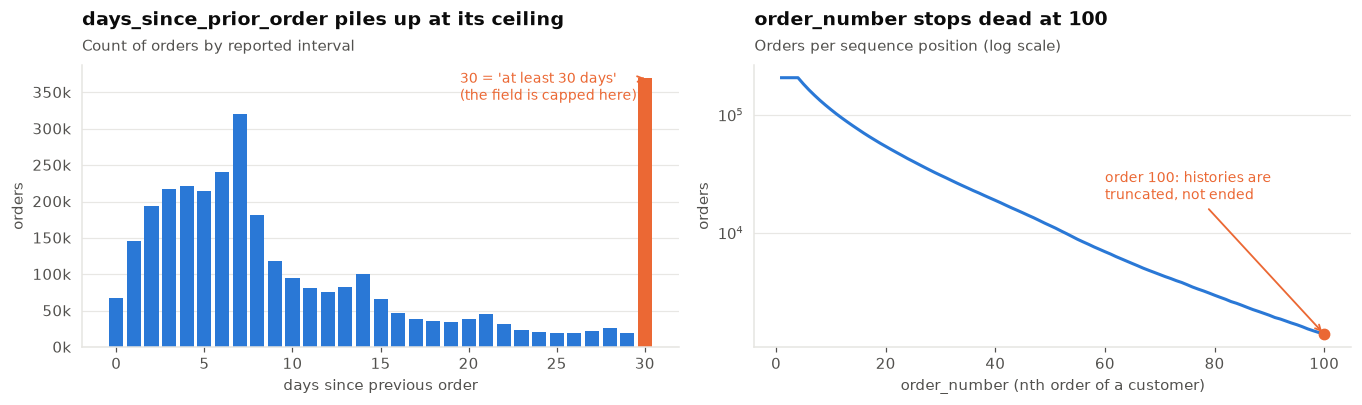

In [15]:
# Two suspicious ceilings
cap30 = int((orders.days_since_prior_order == 30).sum())
cap100 = int((orders.order_number == 100).sum())
print(f"orders at exactly days_since_prior_order = 30 : {cap30:,} ({cap30/len(orders)*100:.1f}% of all orders)")
print(f"  value 29: {int((orders.days_since_prior_order==29).sum()):,}   value 30: {cap30:,}  -> a {cap30/int((orders.days_since_prior_order==29).sum()):.0f}x jump")
print(f"customers at exactly order_number = 100     : {cap100:,}")
print(f"  order_number 99: {int((orders.order_number==99).sum()):,}  order_number 100: {cap100:,}")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8))
h = orders.days_since_prior_order.value_counts().sort_index()
axes[0].bar(h.index, h.values, color=ic.PALETTE["s1"], width=.8)
axes[0].bar([30], [h.loc[30]], color=ic.PALETTE["s2"], width=.8)
axes[0].annotate("30 = 'at least 30 days'\n(the field is capped here)", xy=(30, h.loc[30]),
                 xytext=(19.5, h.loc[30]*0.92), fontsize=9, color=ic.PALETTE["s2"],
                 arrowprops=dict(arrowstyle="->", color=ic.PALETTE["s2"], lw=1.2))
ic.finish(axes[0], "days_since_prior_order piles up at its ceiling",
          "Count of orders by reported interval", "days since previous order", "orders")
axes[0].yaxis.set_major_formatter(lambda v, p: f"{v/1000:.0f}k")

o = orders.order_number.value_counts().sort_index()
axes[1].plot(o.index, o.values, color=ic.PALETTE["s1"], lw=2)
axes[1].scatter([100], [o.loc[100]], color=ic.PALETTE["s2"], s=45, zorder=5)
axes[1].annotate("order 100: histories are\ntruncated, not ended", xy=(100, o.loc[100]),
                 xytext=(60, o.loc[100]*14), fontsize=9, color=ic.PALETTE["s2"],
                 arrowprops=dict(arrowstyle="->", color=ic.PALETTE["s2"], lw=1.2))
axes[1].set_yscale("log")
ic.finish(axes[1], "order_number stops dead at 100",
          "Orders per sequence position (log scale)", "order_number (nth order of a customer)", "orders")
fig.tight_layout(); ic.savefig(fig, "01_quality_ceilings"); plt.show()

**Quality finding 3 — two artificial ceilings that would distort averages.**

* `days_since_prior_order` is **capped at 30**. 369,323 orders (10.8%) report exactly 30
  days, against 18,418 at 29 days — a 20x cliff that no real behaviour produces. "30"
  means *"at least 30 days"*. Treating it as a literal 30 understates the true gap for
  lapsed customers, so the average interval must be reported both ways.
* `order_number` is **capped at 100**. 1,374 customers sit exactly on it. Their histories
  are truncated by the data collection, not finished. Any statement about the most loyal
  customers has to say so.

Neither is an error to fix. Both are limits to carry forward.

### Placeholder categories

A "top category" ranking is worthless if an "unknown" bucket can win it.

In [16]:
ph = (prods.merge(aisles, on="aisle_id").merge(depts, on="department_id"))
print("Departments / aisles whose name is a placeholder rather than a real category:")
display(depts[depts.department.isin(["missing","other"])])
display(aisles[aisles.aisle.isin(["missing","other"])])
print(f"products sitting in department 'missing': {int((ph.department=='missing').sum()):,}")
print(f"products sitting in aisle 'missing' or 'other': {int(ph.aisle.isin(['missing','other']).sum()):,}")

Departments / aisles whose name is a placeholder rather than a real category:


,department_id,department
1,2,other
20,21,missing


,aisle_id,aisle
5,6,other
99,100,missing


products sitting in department 'missing': 1,258
products sitting in aisle 'missing' or 'other': 1,806


**Quality finding 4 — the category tree contains "unknown" buckets.**
`department_id 21` is literally named `missing`, and aisles 100 (`missing`) and 6 (`other`)
are the same thing one level down. 1,258 products live there. They are kept — they
represent real purchases — but they must be *flagged*, so that no chart ever presents
"missing" as a category insight. (Aisle 108, `other creams cheeses`, is a real shelf
despite the word "other", and is not flagged.)

### Distributions

Shape first, statistics second. The mean of a skewed distribution is a bad summary and we
need to know that before we quote one.

In [17]:
items_all = pd.concat([prior, train], ignore_index=True)
basket = items_all.groupby("order_id").size()
orders_per_user = orders.groupby("user_id").size()

dist = pd.DataFrame({
    "basket size (items per order)": basket.describe(),
    "orders per customer": orders_per_user.describe(),
    "days since prior order": orders.days_since_prior_order.describe(),
    "add_to_cart position": items_all.add_to_cart_order.describe(),
}).T
dist["skew"] = [basket.skew(), orders_per_user.skew(),
                orders.days_since_prior_order.skew(), items_all.add_to_cart_order.skew()]
display(dist.round(2))

,count,mean,std,min,25%,50%,75%,max,skew
basket size (items per order),3346083.0,10.11,7.54,1.0,5.0,8.0,14.0,145.0,1.56
orders per customer,206209.0,16.59,16.65,4.0,6.0,10.0,20.0,100.0,2.40
days since prior order,3214874.0,11.11,9.21,0.0,4.0,7.0,15.0,30.0,0.99
add_to_cart position,33819106.0,8.37,7.14,1.0,3.0,6.0,11.0,145.0,1.81


  figure -> reports/figures/01_distributions.png


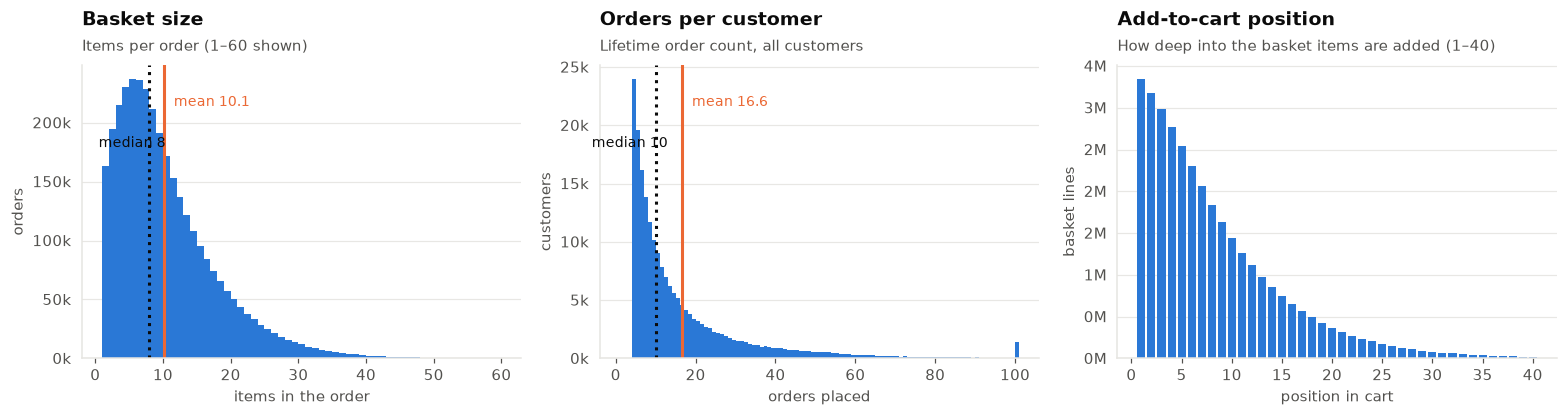

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.9))
axes[0].hist(basket, bins=range(1, 61), color=ic.PALETTE["s1"])
axes[0].axvline(basket.mean(), color=ic.PALETTE["s2"], lw=2)
axes[0].axvline(basket.median(), color=ic.PALETTE["ink"], lw=2, ls=":")
axes[0].text(basket.mean()+1.5, axes[0].get_ylim()[1]*.86, f"mean {basket.mean():.1f}",
             color=ic.PALETTE["s2"], fontsize=9)
axes[0].text(basket.median()-7.5, axes[0].get_ylim()[1]*.72, f"median {basket.median():.0f}",
             color=ic.PALETTE["ink"], fontsize=9)
ic.finish(axes[0], "Basket size", "Items per order (1–60 shown)", "items in the order", "orders")
axes[0].yaxis.set_major_formatter(lambda v,p: f"{v/1000:.0f}k")

axes[1].hist(orders_per_user, bins=range(1, 102), color=ic.PALETTE["s1"])
axes[1].axvline(orders_per_user.mean(), color=ic.PALETTE["s2"], lw=2)
axes[1].axvline(orders_per_user.median(), color=ic.PALETTE["ink"], lw=2, ls=":")
axes[1].text(orders_per_user.mean()+2.5, axes[1].get_ylim()[1]*.86, f"mean {orders_per_user.mean():.1f}",
             color=ic.PALETTE["s2"], fontsize=9)
axes[1].text(orders_per_user.median()-16, axes[1].get_ylim()[1]*.72, f"median {orders_per_user.median():.0f}",
             color=ic.PALETTE["ink"], fontsize=9)
ic.finish(axes[1], "Orders per customer", "Lifetime order count, all customers", "orders placed", "customers")
axes[1].yaxis.set_major_formatter(lambda v,p: f"{v/1000:.0f}k")

pos = items_all.add_to_cart_order.value_counts().sort_index().head(40)
axes[2].bar(pos.index, pos.values, color=ic.PALETTE["s1"])
ic.finish(axes[2], "Add-to-cart position", "How deep into the basket items are added (1–40)",
          "position in cart", "basket lines")
axes[2].yaxis.set_major_formatter(lambda v,p: f"{v/1e6:.0f}M")
fig.tight_layout(); ic.savefig(fig, "01_distributions"); plt.show()

**Quality finding 5 — every behavioural distribution is right-skewed.**
Basket size: mean 10.1 vs median 8 (skew 1.6). Orders per customer: mean 16.6 vs median 10
(skew 2.4). In both cases the mean sits well above the median, so **the mean describes a
customer who doesn't exist**. Every distribution in this project is therefore reported with
its median and its spread alongside the mean, and the customer segmentation in notebook 04
log-transforms order count before clustering — otherwise a handful of 100-order customers
would define the whole distance space.

Note also the absence of outlier *errors*: the largest basket is 145 items and the busiest
customer has 100 orders. Both are extreme but entirely plausible for grocery. There is no
negative quantity, no future date, no impossible hour. **Nothing here needs deleting.**

## 1.6 Which orders can actually be analysed?

In [19]:
es = orders.groupby("eval_set").agg(orders=("order_id","size"), customers=("user_id","nunique"))
es["contents released"] = ["yes — full history", "no — holdout", "yes — most recent order"]
es["usable for item-level analysis"] = ["yes", "no", "yes"]
display(es)
print(f"Total customers: {orders.user_id.nunique():,}")
print(f"Orders with usable contents: {len(orders) - 75000:,} of {len(orders):,} ({(1-75000/len(orders))*100:.1f}%)")
print(f"Basket lines available: {len(items_all):,}")

,orders,customers,contents released,usable for item-level analysis
eval_set,,,,
prior,3214874,206209,yes — full history,yes
test,75000,75000,no — holdout,no
train,131209,131209,yes — most recent order,yes


Total customers: 206,209
Orders with usable contents: 3,346,083 of 3,421,083 (97.8%)
Basket lines available: 33,819,106


Every customer appears in `prior`, so **no customer is lost** — we only lose the final
basket of the 75,000 `test` customers. Order-level analysis (timing, frequency, intervals)
can use all 3,421,083 orders because `order_dow`, `order_hour_of_day` and
`days_since_prior_order` are populated regardless of `eval_set`. Item-level analysis
(products, categories, reorders, baskets) uses the 3,346,083 orders whose contents exist.
That split is stated in every table that follows.

## 1.7 Initial Data Quality Report — summary

| # | Finding | Severity | Decision taken in notebook 02 |
|---|---|---|---|
| 1 | 206,209 nulls in `days_since_prior_order`, all on first orders | **not a defect** | keep as null + add `is_first_order` flag; never impute |
| 2 | 99 product names shared across product_ids (80 within one aisle) | medium — distorts product rankings | add `product_uid` that merges same-name-same-aisle ids; keep `product_id` intact |
| 3 | `days_since_prior_order` capped at 30 (10.8% of orders); `order_number` capped at 100 | medium — distorts averages | flag `dspo_is_capped`; report interval with and without the cap |
| 4 | `missing` / `other` placeholder department and aisles (1,258 products) | medium — pollutes category rankings | flag `is_placeholder`; exclude from category *rankings*, keep in totals |
| 5 | All behavioural distributions right-skewed | design constraint | report median + spread; log-transform order count before clustering |
| 6 | `order_dow` has no documented day mapping | low — presentation only | label with a stated assumption (0 = Saturday); never let a conclusion depend on it |
| 7 | 75,000 `test` orders have no contents | structural | excluded from item-level analysis, retained for order-level timing |
| 8 | Zero orphan foreign keys, zero duplicate rows, zero invalid codes | **clean** | no action; used as the join-integrity baseline |

**Bottom line: this dataset needs almost no repair, and that is the finding.** What it
needs is *interpretation* — four of the eight items above are about not misreading a
field, not about fixing it. There is no justification anywhere here for deleting a row.

In [20]:
qr = pd.DataFrame([
 (1,"days_since_prior_order nulls (206,209)","not a defect","keep + flag is_first_order; no imputation"),
 (2,"99 duplicate product names (80 same-aisle)","medium","add product_uid; keep product_id"),
 (3,"dspo capped at 30 (10.8%); order_number capped at 100","medium","flag; report interval both ways"),
 (4,"'missing'/'other' placeholder categories (1,258 products)","medium","flag is_placeholder; exclude from rankings"),
 (5,"all behavioural distributions right-skewed","design constraint","median + spread; log before clustering"),
 (6,"order_dow mapping undocumented","low","label with stated assumption"),
 (7,"75,000 test orders have no contents","structural","order-level only"),
 (8,"no orphan FKs / duplicate rows / invalid codes","clean","join-integrity baseline"),
], columns=["#","finding","severity","decision"])
ic.savetable(qr, "data_quality_report")
display(qr)
print("\nPhase 1 complete. Deliverables written:")
print("  reports/tables/data_dictionary.csv")
print("  reports/tables/data_quality_report.csv")
print("  reports/figures/01_quality_ceilings.png, 01_distributions.png")

  table  -> reports/tables/data_quality_report.csv  (8 rows)


,#,finding,severity,decision
0,1,"days_since_prior_order nulls (206,209)",not a defect,keep + flag is_first_order; no imputation
1,2,99 duplicate product names (80 same-aisle),medium,add product_uid; keep product_id
2,3,dspo capped at 30 (10.8%); order_number capped...,medium,flag; report interval both ways
3,4,"'missing'/'other' placeholder categories (1,25...",medium,flag is_placeholder; exclude from rankings
4,5,all behavioural distributions right-skewed,design constraint,median + spread; log before clustering
5,6,order_dow mapping undocumented,low,label with stated assumption
6,7,"75,000 test orders have no contents",structural,order-level only
7,8,no orphan FKs / duplicate rows / invalid codes,clean,join-integrity baseline



Phase 1 complete. Deliverables written:
  reports/tables/data_dictionary.csv
  reports/tables/data_quality_report.csv
  reports/figures/01_quality_ceilings.png, 01_distributions.png
